
Estimate sound pressure level from audio recordings
===================================================

Sound pressure level (dB SPL) is a quantitative value that allows comparison of audio
recordings coming from different datasets and environments. Sound pressure level
corresponds to a quantitative measurement of the acoustic pressure energy.
An Automated Recording Unit (ARU) can be converted into a pseudo sound meter level
knowing few parameters: the sensitivity of the microphone, the amplification
gain, the bit depth and the voltage range of the analog to digital converter.
This is sufficient to convert a wav file (array of intergers) into pressure
(Pa). Of course, as the frequency response of the ARUs's microphone is never flat,
the result is an approximation of the real sound pressure level. In order to be
more precise, one should correct the frequency response of the microphone.

In this example, we will evaluate the variation of the sound pressure level
of the ambient sound in a cold temperate forest in France during 24h.


Set variables
-------------
It is very important to always keep the parameters of the ARU that was used
to collect the audio dataset. This is a mandatory to compute the sound
pressure level of the audio file (dB SPL) as a sound meter level would do.
For this experiment, we used a Songmeter 4 (SM4, from Wildlife Acoustics)
with an amplification gain of 16dB.



In [1]:
S = -18         # Sensibility of the microphone -35dBV (SM4) / -18dBV (Audiomoth)
G = 16       # Total amplification gain in dB (SM4 has a +26dB preamplifier)
VADC = 2        # Voltage range of the analog to digital converter (ADC)

## Step 1 - Setup the environment
---

Get the information about the virtual machine that Google gave you

In [2]:
# get info about the virtual machine
!lscpu |grep 'Model name'
!lscpu |grep 'Core(s) per socket:'
!free -h --si | awk  '/Mem:/{print $2}'

Model name:                         13th Gen Intel(R) Core(TM) i7-13700H
Core(s) per socket:                 14
63G


### 1.1 Global settings

Change or adapt the settings :
- to import the required packages
- to set the directories and the paths
- to set some global constatns
- to set the parameters for bambird

In [5]:
# Load basic packages
# --------------------
import shutil
import numpy as np
from pathlib import Path
import os
import datetime
import yaml
import sys
import pandas as pd
import matplotlib.pyplot as plt

from maad import sound, util, spl

In [39]:
# Define constants
# ----------------

# add shortcut to the link (https://drive.google.com/drive/folders/13OVJdujQoG5zjLwLVwC16mxUDNmGFNXb?usp=share_link)
# into your own googledrdive in order to have access to the remote folder
# !!! NEED TO BE ADAPTED TO YOU OWN CONFIG !!!
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Mock-Dataset/active/canopy_dome_10b_32khz')
ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Mock-Dataset/active/canopy_dome_01a_32khz')

SAVE_PATH       = Path('/media/haupert/data/mes_projets/05_xprize/final')

# subsample the dataframe containing all the audio recordings
EVERY_N_ROWS = 1 # Set to 1 to keep all files.

### 1.2 Define some local functions

In [4]:
# To convert the filename into date
def date_from_filename (filename) :
  # filename with format 'XXXX_yyyymmdd_hhmmss.wav'
  # extract year, month, day, hour, minute and second from the filename
  # notice the underscore _ which splits the filename into several parts
  year = int(filename.split('_')[1][0:4])
  month = int(filename.split('_')[1][4:6])
  day = int(filename.split('_')[1][6:8])
  hour = int(filename.split('_')[2][0:2])
  minute = int(filename.split('_')[2][2:4])
  #second = int(filename.split('_')[2][4:6])
  second = 00

  # create a datetime object from the extracted parameters
  date = datetime.datetime(year, month, day, hour, minute, second)

  return date

### 1.3 Connexion to Google Drive
Choose if the data will be copied/saved in your local GoogleDrive (*'/content/drive'*) or in the temporary folder */content* that belongs to this session (everything will be lost after the end of the session (max 12h))

If you chose to store the data in your local GoogleDrive, **modify DATA_PATH, PACKAGE_PATH and SAVE_PATH** according to where you want to store the data and on which name (the most convenient way would be to save the content under the name of the notebook)

Uncheck the box to store the data on your personal Google Drive

In [ ]:

if VIRTUAL_DIR == True :
  DATA_PATH = '/content/DATASETS' # everything will be lost after the end of the session (max 12h)
  SAVE_PATH = '/content/RESULTS'
  PACKAGE_PATH = '/content/PACKAGES'
else :
  from google.colab import drive
  drive.mount('/content/drive')
  DATA_PATH = Path('/content/drive/MyDrive/') / PROJECT_PATH / Path('workflow/bamscape/DATASETS') # data will be saved in your GoogleDrive
  SAVE_PATH = Path('/content/drive/MyDrive/') / PROJECT_PATH / Path('workflow/bamscape/RESULTS')
  PACKAGE_PATH = Path('/content/drive/MyDrive/') / PROJECT_PATH / Path('workflow/bamscape/PACKAGES')

# create the folders and subfolders
try:
  os.makedirs(DATA_PATH)
except FileExistsError:
  # directory already exists
  print("directory {} already exists".format(DATA_PATH))
  pass

try:
  os.makedirs(SAVE_PATH)
except FileExistsError:
  # directory already exists
  print("directory {} already exists".format(SAVE_PATH))
  pass

try:
  os.makedirs(PACKAGE_PATH)
except FileExistsError:
  # directory already exists
  print("directory {} already exists".format(PACKAGE_PATH))
  pass


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
directory /content/drive/MyDrive/XPRIZE/Xprize Rainforest/workflow/bamscape/DATASETS already exists
directory /content/drive/MyDrive/XPRIZE/Xprize Rainforest/workflow/bamscape/RESULTS already exists
directory /content/drive/MyDrive/XPRIZE/Xprize Rainforest/workflow/bamscape/PACKAGES already exists


## Step 2 - Process audio
---


### Grab audio
First, we parse the directory /indices in order to get a DataFrame with date
and fullfilename. As the data was collected with a SM4 audio recording device,
we set the dateformat agument to 'SM4' in order to be able to parse the date
from the filename. In case of Audiomoth, the date is coded as Hex in the
filename.



In [20]:
# Grab audio
# -------------------
df = util.date_parser(str(ARCHIVE_PATH), verbose=False)

# print the number of audio recordings
print("The number of audio recordings is %d" %len(df))


The number of audio recordings is 384


Subsamples the dataframe in order to make quick tests

In [21]:
# Keep rows every N rows
df = df.iloc[::EVERY_N_ROWS, :]

# print the number of audio recordings
print("The number of audio recordings that will be processed is %d" %len(df))

The number of audio recordings that will be processed is 384


Load and preprocess audio
-------------------------
Then we process all the files found in the directory /indices.
Initialisation of an empty dataframe df_spl to store all the dB SPL values
extracted from the whole audio dataset.



In [22]:
df_spl = pd.DataFrame()

# Main loop to go through all audio files
for index, row in df.iterrows() :

    # initialisation of an empty list to store the dB SPL of the current
    # audio recording.
    leq_list = []

    # get the full filename of the corresponding row
    fullfilename = row['file']
    # Save file basename
    path, filename = os.path.split(fullfilename)
    print ('\n**************************************************************')
    print (filename)

    #### Load the original sound (16bits, only left channel) and get the sampling
    # frequency fs
    try :
        wave,fs = sound.load(filename=fullfilename, channel='left', detrend=True, verbose=False)

    except:
        # Delete the row if the file does not exist or raise a value error (i.e. no EOF)
        df.drop(index, inplace=True)
        continue

    """ =======================================================================
                     Computation in the frequency domain
    ========================================================================"""

    # Compute the Power Spectrogram Density (PSD) : Sxx_power
    Sxx_power,tn,fn,ext = sound.spectrogram (wave, fs, window='hamming',
                                             nperseg = 1024, noverlap=1024//2,
                                             verbose = False, display = False,
                                             savefig = None)


    #### Average PSD (It's a mandatory to compute the mean on the PSD for
    # energy conservation)
    mean_PSD = np.mean(Sxx_power, axis = 1)

    #### Compute the Leq of each frequency band (1kHz step)
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(0,1000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(1000,2000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[ spl.psd2leq(mean_PSD[util.index_bw(fn,(2000,3000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(3000,4000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(4000,5000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(5000,6000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(6000,7000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(7000,8000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(8000,9000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(9000,10000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(10000,11000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(11000,12000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(12000,13000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(13000,14000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(14000,15000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]
    leq_list+=[spl.psd2leq(mean_PSD[util.index_bw(fn,(15000,16000))],
                               gain=G,
                               sensitivity=S,
                               Vadc=VADC)]


    #### Create a dataframe from the list
    df_leq = pd.DataFrame([leq_list],
                          columns = ['0-1kHz',
                                     '1-2kHz',
                                     '2-3kHz',
                                     '3-4kHz',
                                     '4-5kHz',
                                     '5-6kHz',
                                     '6-7kHz',
                                     '7-8kHz',
                                     '8-9kHz',
                                     '9-10kHz',
                                     '10-11kHz',
                                     '11-12kHz',
                                     '12-13kHz',
                                     '13-14kHz',
                                     '14-15kHz',
                                     '15-16kHz',
                                     ])
    
    """ =======================================================================
                    Create a dataframe
    ========================================================================"""
    #### We create a dataframe from row that contains the date and the
    # full filename. This is done by creating a DataFrame from row (ie. TimeSeries)
    # then transposing the DataFrame.
    df_row = pd.DataFrame(row)
    df_row =df_row.T
    df_row.index.name = 'Date'
    df_row = df_row.reset_index()

    #### add Leq values into the df_spl dataframe
    df_spl = pd.concat([df_spl,pd.concat([df_row, df_leq], axis=1)], axis=0)

#### When the loop ends, set Date as index
df_spl = df_spl.set_index('Date')

#### remove the column file
df_spl = df_spl.drop(columns=['file'])


**************************************************************
cupula-1_20240516_163203.wav

**************************************************************
cupula-1_20240516_163403.wav

**************************************************************
cupula-1_20240516_163602.wav

**************************************************************
cupula-1_20240516_163803.wav

**************************************************************
cupula-1_20240516_164002.wav

**************************************************************
cupula-1_20240516_164203.wav

**************************************************************
cupula-1_20240516_164403.wav

**************************************************************
cupula-1_20240516_164603.wav

**************************************************************
cupula-1_20240516_164803.wav

**************************************************************
cupula-1_20240516_165003.wav

**************************************************************
cupula

In [25]:
df_spl

,0-1kHz,1-2kHz,2-3kHz,3-4kHz,4-5kHz,5-6kHz,6-7kHz,7-8kHz,8-9kHz,9-10kHz,10-11kHz,11-12kHz,12-13kHz,13-14kHz,14-15kHz,15-16kHz
Date,,,,,,,,,,,,,,,,
2024-05-16 16:32:03,59.973018,43.679765,43.563404,41.104347,40.524735,38.809657,37.086970,36.936383,36.326900,35.923473,35.888770,35.568437,35.864335,36.748887,36.272295,34.823554
2024-05-16 16:34:03,56.841264,38.704686,39.500909,38.204932,40.602990,36.103308,36.235277,36.080138,35.349913,36.275207,36.042863,35.864805,35.455883,37.440862,37.534131,35.055594
2024-05-16 16:36:02,61.681996,40.004994,38.089755,36.090852,34.877304,34.443696,34.280720,34.458016,34.942779,35.478961,35.667248,35.500225,35.608907,38.181337,38.038701,34.975032
2024-05-16 16:38:03,59.488104,37.485436,39.849772,39.996292,42.058899,41.115998,36.785722,35.844805,36.008681,36.081746,36.194106,35.854325,35.906890,37.284915,37.093951,34.992741
2024-05-16 16:40:02,55.908549,36.353971,35.980772,36.100282,35.768200,35.600090,35.138786,34.785455,34.604211,35.355062,35.623523,35.622217,35.394445,37.220077,37.201776,34.934183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-17 05:10:04,52.990370,35.909757,34.266828,33.597088,34.497108,34.360806,33.716852,33.904631,35.102288,35.948044,35.994819,36.088449,35.733384,35.709989,38.476454,38.046939
2024-05-17 05:12:03,53.860045,36.378725,34.241043,33.529718,34.370546,34.432085,33.348082,33.756632,34.584790,35.483627,35.798193,35.834987,35.504707,35.461979,37.672550,37.232433
2024-05-17 05:14:03,48.452549,35.734926,34.065757,33.482192,34.231616,34.350525,33.358046,33.757282,34.708871,35.590621,35.853687,35.921116,35.563199,35.569275,38.735513,38.350960


## Save the results

In [40]:
# save
filename = ARCHIVE_PATH.stem + '_spl.csv'
df_spl.to_csv(SAVE_PATH / filename, index=True)

Display results
---------------
Display Leq (dB SPL) dynamics for each frequency band.
One can observe that most of the acoustic energy is between 0-1kHz. Moreover
the sound pressure level of the 0-1kHz frequency band is not constant but
increases during the day, from 4am to 22pm with a maximum between at 10am
This is mainly due to the airplanes flying over the forest during the day.
One can also observe that the energy of the biophony is really lower than
the energy of the low frequency band. The sound pressure level of the biophony
is the highest between 5am to 9am, which corresponds to the dawn chorus



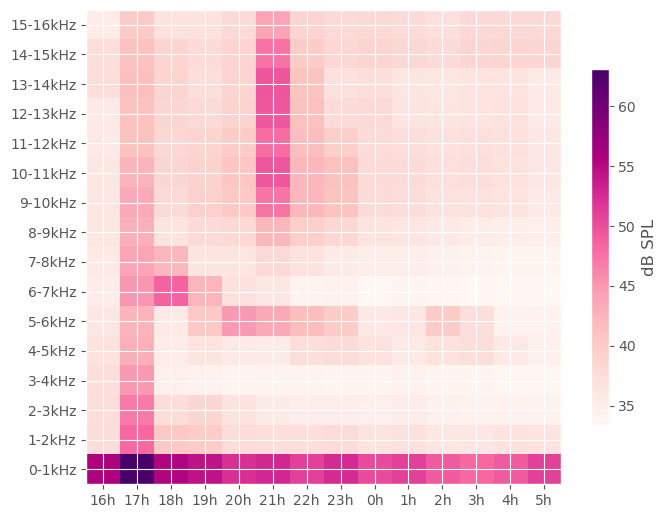

In [38]:
# Mean values by hour
df_spl_mean = df_spl.groupby(df_spl.index.hour).mean()

# rearrange the hour
df_spl_part1 = df_spl_mean[df_spl_mean.index >= 16]
df_spl_part1.sort_index(ascending = True, inplace=True)
df_spl_part2 = df_spl_mean[df_spl_mean.index < 16]
df_spl_part2.sort_index(inplace=True)
df_spl_sorted = pd.concat([df_spl_part1, df_spl_part2], axis=0)
df_spl_rev_order = df_spl_sorted.iloc[:,::-1]

# Get the list of unique index of type 'hour'
x_label = [i + j for i, j in zip(map(str, df_spl_rev_order.index.values), ["h"] * len(df_spl_rev_order))]

# kwargs
plt.style.use('ggplot')
cmap = "RdPu"

# plot
fig = plt.figure(figsize=(len(df_spl_rev_order)*0.50, len(list(df_spl_rev_order))*0.33))
ax = fig.add_subplot(111)
caxes = ax.matshow(df_spl_rev_order.transpose(), cmap=cmap, aspect="auto")

fig.colorbar(caxes, shrink=0.75, label="dB SPL")
# Set ticks on both sides of axes on
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
# We want to show all ticks...
ax.set_yticks(np.arange(len(df_spl_rev_order.columns)))
ax.set_xticks(np.arange(len(x_label)))
# ... and label them with the respective list entries
ax.set_yticklabels(df_spl_rev_order.columns)
ax.set_xticklabels(x_label)
# Rotate the tick labels and set their alignment.
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=10)
fig.tight_layout()
plt.show()


Display the comparison between the dynamics of the Leq (dB SPL) corresponding
mainly to the anthropophony (frequency band 0-1kHz) and the biophony
(frequency band 1-16kHz)



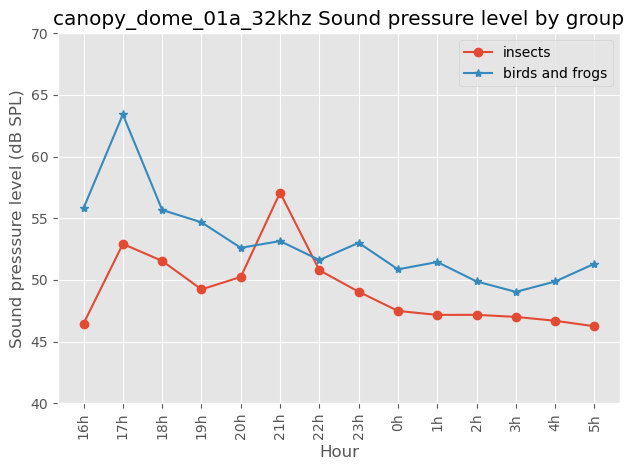

In [48]:
# add the energy in dB in the anthropophony (0-1kHz) and biophony bands (2-16kHz)
insect = df_spl_sorted.iloc[:,5:].apply(util.add_dB, axis=1)
insect.index = x_label

bird_frogs = df_spl_sorted.iloc[:,0:5].apply(util.add_dB, axis=1)
bird_frogs.index = x_label

# Plot the Series with index
plt.style.use('ggplot')
insect.plot(marker='o')
bird_frogs.plot(marker='*')

# Set x-axis ticks and labels
plt.xticks(range(len(bird_frogs.index)), bird_frogs.index)
# Rotate x-axis labels if needed
plt.xticks(rotation=90)

# Set labels and title
plt.xlabel('Hour')
plt.ylabel('Sound presssure level (dB SPL)')
plt.title(str(ARCHIVE_PATH.stem)+ ' Sound pressure level by group')
plt.legend(['insects', 'birds and frogs'])

# Set the y-axis limits
plt.ylim(40,70)

# Show the plot
plt.tight_layout()
plt.show()
